In [10]:
# !pip install torchvision numpy torch matplotlib jax tensorcircuit-ng qiskit pennylane scipy scikit-learn pandas tqdm

In [1]:
import math
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pennylane as qml

from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from tqdm import tqdm
from matplotlib import cm
from scipy.linalg import sqrtm
from sklearn.decomposition import PCA

import jax
import jax.numpy as jnp

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
def scale_data(data, scale=None, dtype=np.float32):
    if scale is None:
        scale = [-1, 1]
    min_data, max_data = [float(np.min(data)), float(np.max(data))]
    min_scale, max_scale = [float(scale[0]), float(scale[1])]
    data = ((max_scale - min_scale) * (data - min_data) / (max_data - min_data)) + min_scale
    return data.astype(dtype)

In [4]:
# Function from https://machinelearningmastery.com/how-to-implement-the-frechet-inception-distance-fid-from-scratch/
def calculate_fid(act1, act2):
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

In [5]:
def get_train_data(dataset='MNIST', ds_class=5):
    if dataset == 'MNIST':
        train_loader = torch.utils.data.DataLoader(datasets.MNIST('../mnist', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    elif dataset == 'Fashion':
        train_loader = torch.utils.data.DataLoader(datasets.FashionMNIST('../fashion', 
                                                                download=True, 
                                                                train=True,
                                                                
                                                                transform=transforms.Compose([
                                                                    torchvision.transforms.ToTensor(),
                                                                    transforms.Lambda(torch.flatten),
                                                                ])), 
                                                batch_size=10000, 
                                                shuffle=True)
    train_data = []
    label_to_keep = ds_class
    label_to_keep_name = str(label_to_keep)
    for (data, labels) in train_loader:
        for x, y in zip(data, labels):
            if y == label_to_keep:
                train_data.append(x.numpy())

    return label_to_keep_name, train_data

In [6]:
label_to_keep_name, train_data = get_train_data(dataset='MNIST')
train_data = scale_data(np.array(train_data), [0,1])
image_size = 5  
batch_size = 8
pca_dims=40
n_qubits = 5  
q_depth = 6 
n_generators = 8

In [7]:
pca = PCA(n_components=pca_dims)
pca_data_full = pca.fit_transform(train_data)
ordering = []

In [8]:
pca_data_full.shape, train_data.shape

((5421, 40), (5421, 784))

In [9]:
for i in range(8):
    k = 4*i
    l = [i, 39-k, 38-k, 37-k, 36-k]
    ordering.append(l)
pca_min, pca_max = np.min(pca_data_full), np.max(pca_data_full)

In [10]:
full_train_data = [(i,j) for i,j in zip(scale_data(pca_data_full), train_data)]

transform = transforms.Compose([transforms.ToTensor()])
dataloader = torch.utils.data.DataLoader(
    scale_data(pca_data_full), batch_size=batch_size, shuffle=True, drop_last=True
)

In [11]:
ordering

[[0, 39, 38, 37, 36],
 [1, 35, 34, 33, 32],
 [2, 31, 30, 29, 28],
 [3, 27, 26, 25, 24],
 [4, 23, 22, 21, 20],
 [5, 19, 18, 17, 16],
 [6, 15, 14, 13, 12],
 [7, 11, 10, 9, 8]]

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(pca_dims, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

In [13]:
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="parameter-shift")
# @qml.qnode(dev, interface="jax", diff_method="parameter-shift")
def quantum_circuit(inputs, weights):
    # weights = weights.reshape(q_depth, n_qubits)
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RX(inputs[i], wires=i)
    # qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='Y')
    # qml.AngleEmbedding(features=inputs, wires=range(n_qubits), rotation='X')
    
    for i in range(q_depth):
        for y in range(n_qubits):
            qml.RY(weights[i][y], wires=y)
        for y in range(n_qubits - 1):
            qml.CZ(wires=[y, y + 1])
    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)]

In [14]:
# v_q_circuit = jax.jit(jax.vmap(quantum_circuit, in_axes=(0, None)))

In [15]:
# Uncomment this line for running on real machines
#@qml.qnode(qml.device(name='qiskit.ibmq', wires=5, backend='ibmq_jakarta', ibmqx_token="ibm_token_here"))
def quantum_cirtui_real_machine(inputs, weights):

    # weights = weights.reshape(q_depth, n_qubits)

    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RX(inputs[i], wires=i)

    # Repeated layer
    for i in range(q_depth):
        for y in range(n_qubits):
            qml.RY(weights[i][y], wires=y)
        for y in range(n_qubits - 1):
            qml.CZ(wires=[y, y + 1])
    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)]

In [16]:
class QuantumGenerator(nn.Module):
    def __init__(self, n_generators, q_delta=1, env='simulation'):
        super().__init__()

        self.q_params = nn.ParameterList(
            [
                nn.Parameter(q_delta * torch.rand(q_depth, n_qubits), requires_grad=True)
                for _ in range(n_generators)
            ]
        )

        self.n_generators = n_generators
        self.env = env

        # weight_shapes = {"weights": (q_depth, n_qubits)}
        # if env == "real":
        #     self.qcircuit = qml.qnn.TorchLayer(quantum_cirtui_real_machine, weight_shapes).to(device)
        # else:
        #     self.qcircuit = qml.qnn.TorchLayer(quantum_circuit, weight_shapes).to(device)

    def forward(self, x):
        images = []
        patch_size = image_size
        images = torch.Tensor(x.size(0), 0).to(device)

        # x_jax = jnp.array(x.detach().cpu().numpy())
        # all_patches = []
        
        for params in self.q_params:
            patches = torch.Tensor(0, patch_size).to(device)
            for elem in x:
                f = quantum_circuit(elem, params)
                if self.env == 'Real':
                    f = quantum_cirtui_real_machine(elem, params)
                f = torch.tensor(f)
                q_out = f.float().unsqueeze(0).to(device)
                patches = torch.cat((patches, q_out))
            flattened_order =  [j for sub in ordering for j in sub]
            patches = torch.flatten(patches)
            patches = patches[flattened_order] # Rearrange order of pca components
            patches = patches.reshape(batch_size, patch_size)
            images = torch.cat((images, patches), 1)
        return images

# Init

In [17]:
lrG = 0.3
lrD = 0.05
num_iter = 1

gen_losses = []
disc_losses = []
discriminator = Discriminator().to(device)
generator = QuantumGenerator(n_generators).to(device)
criterion = nn.BCELoss()
optD = optim.SGD(discriminator.parameters(), lr=lrD)
optG = optim.SGD(generator.parameters(), lr=lrG)
real_labels = torch.full((batch_size,), 1.0, dtype=torch.float, device=device)
fake_labels = torch.full((batch_size,), 0.0, dtype=torch.float, device=device)
counter = 0

noise_upper_bound = math.pi/8

In [18]:
def relu(x):
    return x * (x > 0)
def get_noise_upper_bound(gen_loss, disc_loss, original_ratio):
    R = disc_loss.detach().cpu().numpy()/gen_loss.detach().cpu().numpy()
    return math.pi/8 + (5 *math.pi / 8) * relu(np.tanh((R - (original_ratio))))

In [19]:
original_ratio = None
upper_bounds = [math.pi/8]
results = []
generated_images = []

# Train

In [20]:
print('Training...')
for e in tqdm(range(num_iter)):
    for i, train_pair in enumerate(dataloader):
        pca_data = train_pair
        data = pca_data.reshape(batch_size, pca_dims)
        real_data = data.to(device).to(torch.float32)
        noise = torch.rand(batch_size, n_qubits, device=device) * noise_upper_bound
        fake_data = generator(noise)
        discriminator.zero_grad()
        outD_real = discriminator(real_data).view(-1)
        outD_fake = discriminator(fake_data.detach()).view(-1)
        errD_real = criterion(outD_real, real_labels)
        errD_fake = criterion(outD_fake, fake_labels)
        errD_real.backward()
        errD_fake.backward()
        errG = criterion(outD_fake, real_labels)
        errD = errD_real + errD_fake
        
        # gen_losses.append(errG.detach().cpu().numpy())
        # disc_losses.append(errD.detach().cpu().numpy())
        
        gen_losses.append(errG.detach().cpu().numpy())
        disc_losses.append(errD.detach().cpu().numpy())

        optD.step()

        # Train the generator
        generator.zero_grad()
        outD_fake = discriminator(fake_data).view(-1)
        errG = criterion(outD_fake, real_labels)
        errG.backward()
        optG.step()
        if original_ratio is None:
            original_ratio = errD.detach().cpu().numpy()/errG.detach().cpu().numpy()
        noise_upper_bound = get_noise_upper_bound(errG, errD, original_ratio)
        upper_bounds.append(noise_upper_bound)
        np.save(f'upper_bounds_{label_to_keep_name}', upper_bounds)
        counter += 1      
        if counter % 20 == 0:  
            test_images = generator(noise).detach().cpu().numpy()
            test_images = pca.inverse_transform(test_images)
            fid = calculate_fid(test_images.reshape([batch_size, 784]), train_data)
            test_images = scale_data(test_images,[0,1])
            real_images = []
            np.save(f'gen_loss_{label_to_keep_name}', gen_losses)
            np.save(f'disc_loss_{label_to_keep_name}', disc_losses)
            from PIL import Image 
            im = np.reshape(test_images[0], [28, 28])
            new_im = np.zeros([28,28])
            for i in range(28):
                for j in range(28):
                    if im[i][j] > .5:
                        new_im[i][j] = 0.0
                    else:
                        new_im[i][j] = 1.0
            im = Image.fromarray(np.uint8(255-(new_im*255)))
            im = im.save(os.path.join("../QGAN/gen_images_dist",f"{label_to_keep_name}_{counter}.png"))
            torch.save(generator.state_dict(), f"generator_{label_to_keep_name}")
            torch.save(discriminator.state_dict(), f"disc_{label_to_keep_name}")

            print("fid:", fid)

Training...


  0%|                                                                       | 0/1 [00:00<?, ?it/s]/tmp/ipykernel_1424875/4228599007.py:35: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f = torch.tensor(f)
/tmp/ipykernel_1424875/1285097074.py:6: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


fid: 46.14981075370248


/tmp/ipykernel_1424875/1285097074.py:6: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


fid: 45.69006320429789


...

/tmp/ipykernel_1424875/1285097074.py:6: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


fid: 45.624149266144585


/tmp/ipykernel_1424875/1285097074.py:6: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


fid: 45.941077416103845


100%|██████████████████████████████████████████████████████████████| 1/1 [11:50<00:00, 710.02s/it]


# Test

In [25]:
# tr1 = "QGAN/tr1"
tr1 = "5"

# tr2 = "QGAN/tr2"
tr2 = "5"

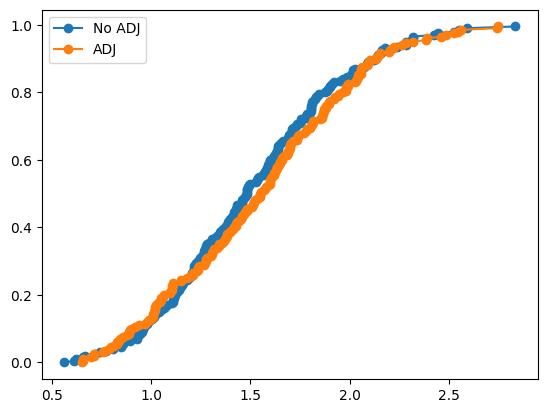

In [28]:
vars = []
for label in [tr1, tr2]:
    var = []
    label_to_keep_name = label
    generator.load_state_dict(torch.load(f"generator_{label_to_keep_name}"))
    outputs = np.zeros([25, 8, 784])
    noise_max = np.load(f'upper_bounds_{label_to_keep_name}.npy')
    for i in range(25):
        noise = torch.rand(8, n_qubits, device=device).cpu() * noise_max[i]
        output = pca.inverse_transform(generator(noise).detach().cpu().numpy())
        outputs[i] = output
    outputs = outputs.reshape([200, 784])
    mean = np.mean(outputs, axis=0)
    for i in range(outputs.shape[0]):
        var.append(np.sum(np.square(outputs[i] - mean)))
    x = np.sort(var)
    y = np.arange(200) / float(200)
    vars.append((x,y))
plt.plot(vars[0][0], vars[0][1], marker='o', label='No ADJ')
plt.plot(vars[1][0], vars[1][1], marker='o', label='ADJ')
np.save('vars', vars)
plt.legend()
plt.show()

In [99]:
noise_max.shape

(678,)

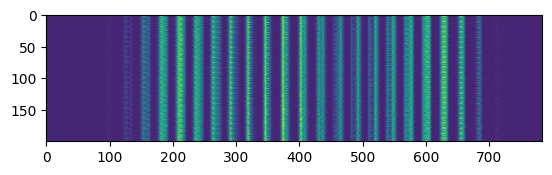

In [33]:
plt.imshow(outputs)

# Breaking down Training

In [39]:
train_pair = next(iter(dataloader))
pca_data = train_pair

In [40]:
train_pair.shape

torch.Size([8, 40])

In [41]:
data = pca_data.reshape(batch_size, pca_dims)

In [43]:
data.shape

torch.Size([8, 40])

In [45]:
real_data = data.to(device).to(torch.float32)
noise = torch.rand(batch_size, n_qubits, device=device) * noise_upper_bound

In [46]:
fake_data = generator(noise)

In [48]:
noise.shape

torch.Size([8, 5])

In [52]:
fake_data.shape

torch.Size([8, 40])

In [53]:
discriminator.zero_grad()

In [54]:
outD_real = discriminator(real_data).view(-1)

In [55]:
outD_fake = discriminator(fake_data.detach()).view(-1)

In [56]:
outD_real

tensor([0.4781, 0.4814, 0.4709, 0.4808, 0.4751, 0.4803, 0.4754, 0.4783],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [57]:
outD_fake

tensor([0.4779, 0.4807, 0.4777, 0.4749, 0.4739, 0.4782, 0.4808, 0.4789],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [61]:
fake_data__pca_inv = pca.inverse_transform(fake_data.detach().cpu().numpy())

In [64]:
fake_data__pca_inv = fake_data__pca_inv.reshape(batch_size, 28, 28)

In [66]:
fake_data__pca_inv.shape

(8, 28, 28)

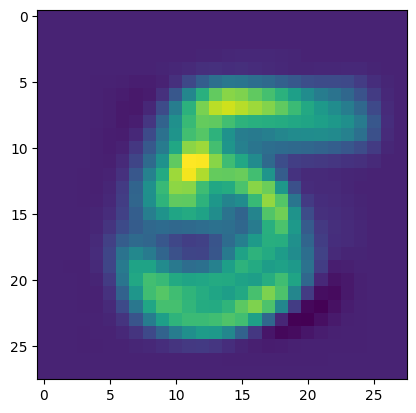

In [72]:
plt.imshow(fake_data__pca_inv[0])

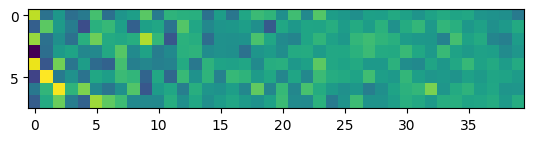

In [74]:
plt.imshow(data)

In [1]:
plt.imshow(fake_data.cpu())

NameError: name 'plt' is not defined